# Exploratory Data Analysis (EDA) - Wine Quality Dataset

## IMPORT LIBRARIES

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

---

## LOAD DATASET

In [5]:
red_wine_df = pd.read_csv("..\\data\\winequality-red.csv", sep=";")
white_wine_df = pd.read_csv("..\\data\\winequality-white.csv", sep=";")

### Merging Red and White Wine Datasets

In [6]:
red_wine_df["type"] = "red"
white_wine_df["type"] = "white"

wine_df = pd.concat([red_wine_df, white_wine_df], ignore_index=True)
wine_df.reset_index(drop=True, inplace=True)


- Dataset: UCI Wine Quality Dataset
- Target variable: quality
- Each row represents chemical properties of wine samples.
---

## DATASET OVERVIEW

In [7]:
print("Shape:", wine_df.shape)
wine_df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [8]:
info_df = pd.DataFrame({
    "Data Type": wine_df.dtypes,
    "Non-Null Count": wine_df.count(),
    "Missing Values": wine_df.isnull().sum()
})

info_df

,Data Type,Non-Null Count,Missing Values
fixed acidity,float64,6497,0
volatile acidity,float64,6497,0
citric acid,float64,6497,0
residual sugar,float64,6497,0
chlorides,float64,6497,0
free sulfur dioxide,float64,6497,0
total sulfur dioxide,float64,6497,0
density,float64,6497,0
pH,float64,6497,0
sulphates,float64,6497,0


In [9]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


The dataset contains 6497 wine samples with 13 variables.  

All features represent physicochemical properties of wine.  

The target variable is **quality**, rated on a scale from 0 to 10.

---

## MISSING VALUES CHECK

In [10]:
wine_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

The dataset does not contain missing values.

Therefore no imputation is required.

---

## TARGET VARIABLE ANALYSIS

<Axes: xlabel='quality', ylabel='count'>

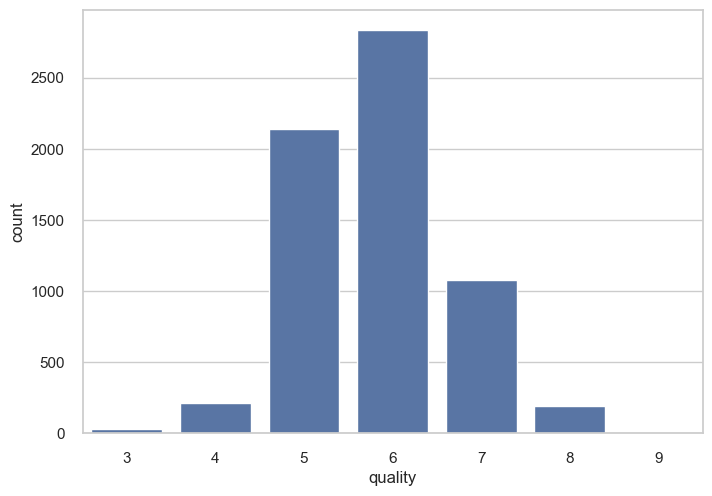

In [11]:
sns.countplot(x="quality", data=wine_df)

Wine quality ranges from 3 to 9.

Most samples are concentrated around quality 5 to 7,
showing a slightly imbalanced distribution.

---

## DISTRIBUTION VISUALIZATION

Text(0, 0.5, 'Count')

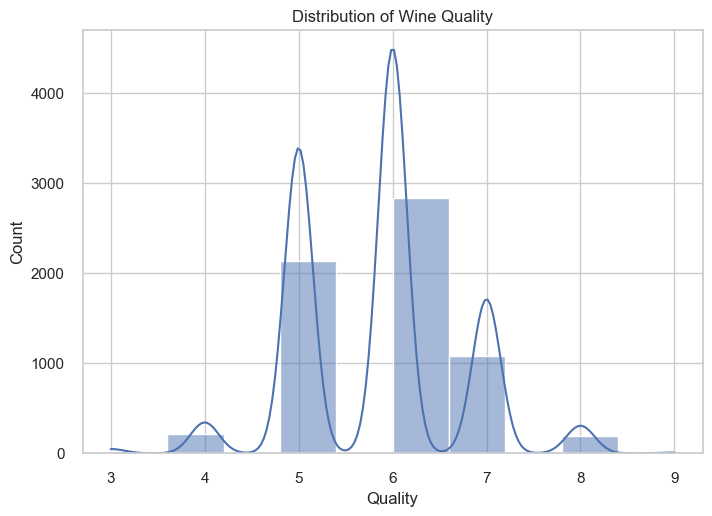

In [12]:
sns.histplot(wine_df['quality'], bins=10, kde=True)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")

The histogram shows that most wines fall between quality 5 and 6.

High quality wines (7+) are relatively rare.

---

## CORRELATION ANALYSIS

Correlation strength interpretation:

- 0.00 – 0.19 : Very weak
- 0.20 – 0.39 : Weak
- 0.40 – 0.59 : Moderate
- 0.60 – 0.79 : Strong
- 0.80 – 1.00 : Very strong

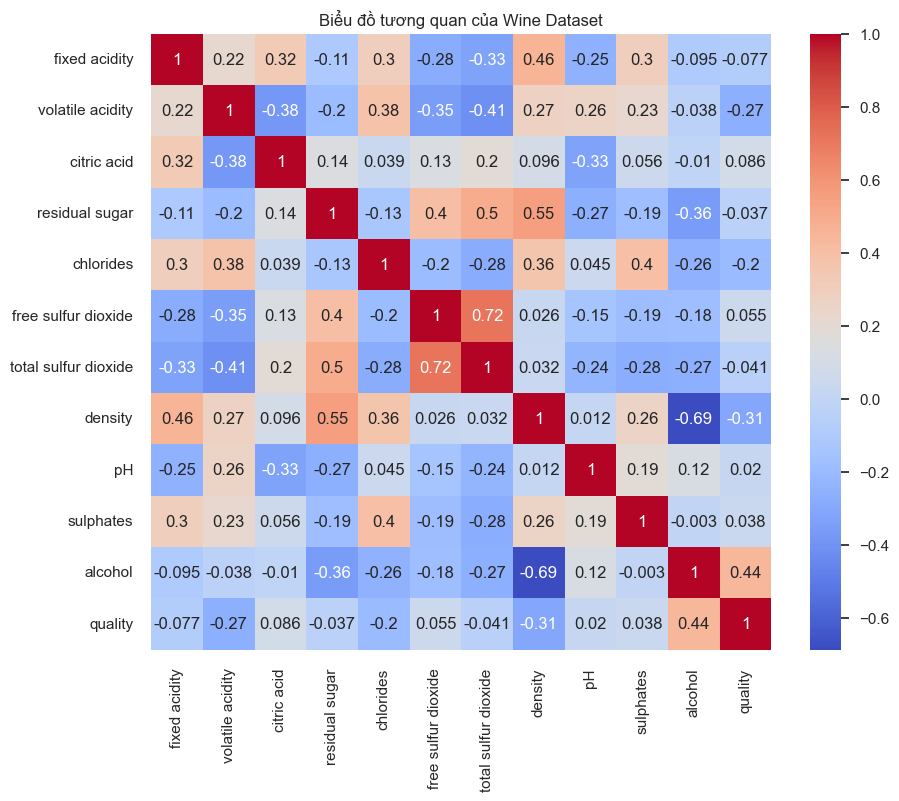

In [13]:
corr = wine_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Biểu đồ tương quan của Wine Dataset")
plt.show()

In [14]:
corr["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

The correlation heatmap shows that alcohol has the strongest positive correlation with wine quality, while volatile acidity shows a negative correlation.

Some features such as fixed acidity and citric acid as well as free sulfur dioxide and total sulfur dioxide show relatively strong correlations with each other.

Overall, most features have moderate or weak correlations, indicating that they provide diverse information for predicting wine quality.

In [15]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().reset_index()
high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr = high_corr[abs(high_corr['Correlation']) >= 0.5]
print(high_corr)      

              Feature 1             Feature 2  Correlation
43       residual sugar               density     0.552517
66  free sulfur dioxide  total sulfur dioxide     0.720934
94              density               alcohol    -0.686745


(|correlation| ≥ 0.5)

Positive correlation: Fixed acidity – citric acid, Fixed acidity – density, Free sulfur dioxide – total sulfur dioxide.

Negative correlation: Fixed acidity – pH, Volatile acidity – citric acid, Citric acid – pH.

---
## OUTLIER ANALYSIS

In [16]:
summary = []

numeric_cols = wine_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    Q1 = wine_df[col].quantile(0.25)
    Q3 = wine_df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = wine_df[(wine_df[col] < Q1 - 1.5*IQR)|
                       (wine_df[col] > Q3 + 1.5*IQR)]

    num_outliers = len(outliers)
    percentage = num_outliers / len(wine_df) * 100

    summary.append([col, num_outliers, percentage])

outlier_df = pd.DataFrame(summary, columns=["Feature", "Outliers", "Percentage (%)"])

outlier_df.index = outlier_df.index + 1

outlier_df

,Feature,Outliers,Percentage (%)
1,fixed acidity,357,5.494844
2,volatile acidity,377,5.802678
3,citric acid,509,7.834385
4,residual sugar,118,1.816223
5,chlorides,286,4.402032
6,free sulfur dioxide,62,0.954287
7,total sulfur dioxide,10,0.153917
8,density,3,0.046175
9,pH,73,1.123596
10,sulphates,191,2.939818


Outliers were detected using the IQR method.

Some features such as residual sugar and chlorides contain a noticeable
percentage of extreme values, which may affect model training.

Further preprocessing may be required depending on the model used.

---

## VISUALIZATION

Text(0.5, 1.0, 'Wine Quality Count')

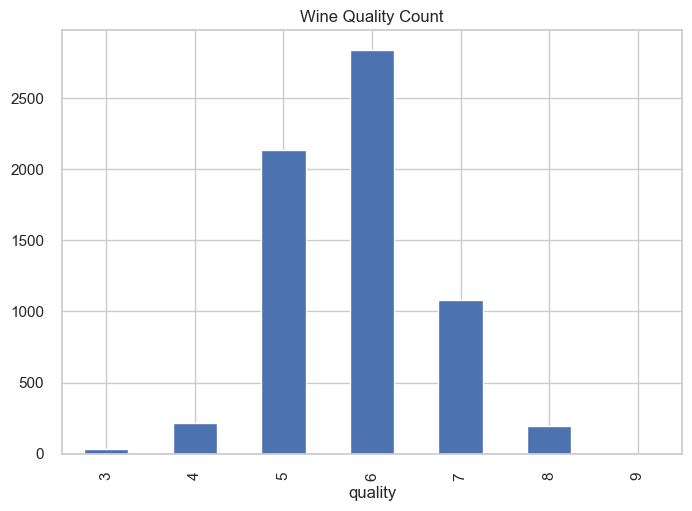

In [17]:
wine_df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Wine Quality Count")

The bar chart confirms that most wine samples are rated **5 or 6**, indicating that the dataset is slightly imbalanced toward medium-quality wines.  
Very low quality (3–4) and high quality (7–8) wines appear much less frequently.

Text(0.5, 1.0, 'Average Alcohol by Quality')

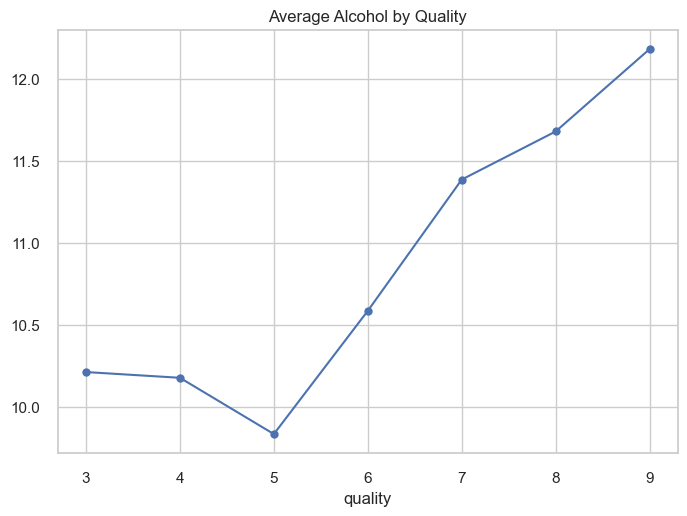

In [18]:
wine_df.groupby("quality")["alcohol"].mean().plot(kind='line', marker='o')
plt.title("Average Alcohol by Quality")

The average alcohol content tends to **increase as wine quality increases**.  
This pattern suggests that alcohol may be an important factor influencing wine quality ratings.

<Axes: >

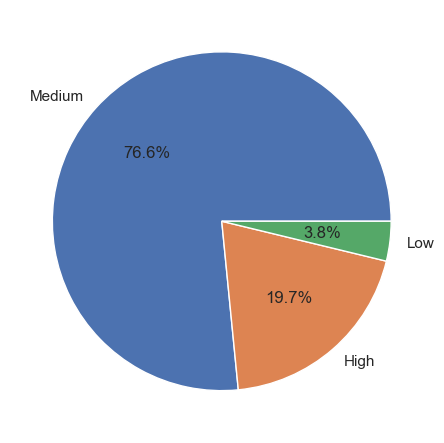

In [19]:
quality_group = pd.cut(wine_df['quality'], bins=[0,4,6,10], labels=['Low','Medium','High'])
quality_group.value_counts().plot(kind='pie', autopct='%1.1f%%')

After grouping the quality scores into three categories (Low, Medium, High),  
most wines fall into the **Medium quality group**, while **High-quality wines are relatively rare**.  
This confirms the moderate imbalance observed earlier.

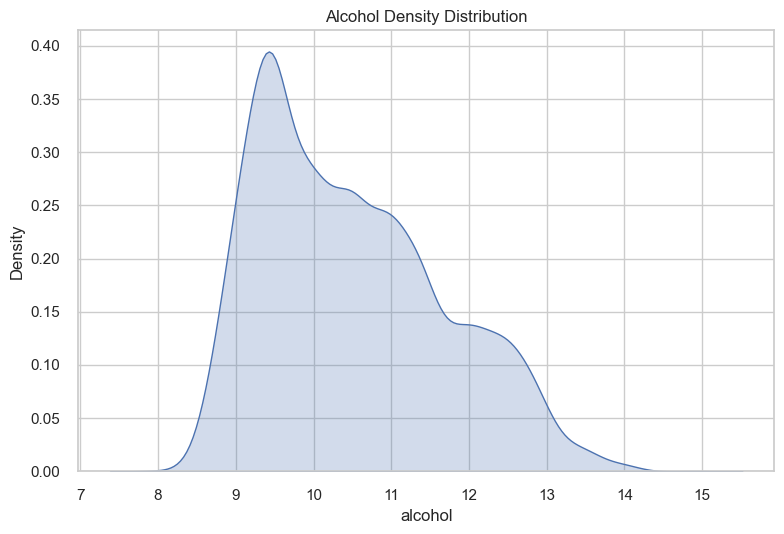

In [20]:
sns.kdeplot(wine_df['alcohol'], fill=True)

plt.title("Alcohol Density Distribution")
plt.tight_layout()
plt.show()

The alcohol distribution appears slightly **right-skewed**, with most wines having alcohol content between **9% and 11%**.  
Only a small portion of wines have very high alcohol levels.

---


## FEATURE RELATIONSHIP

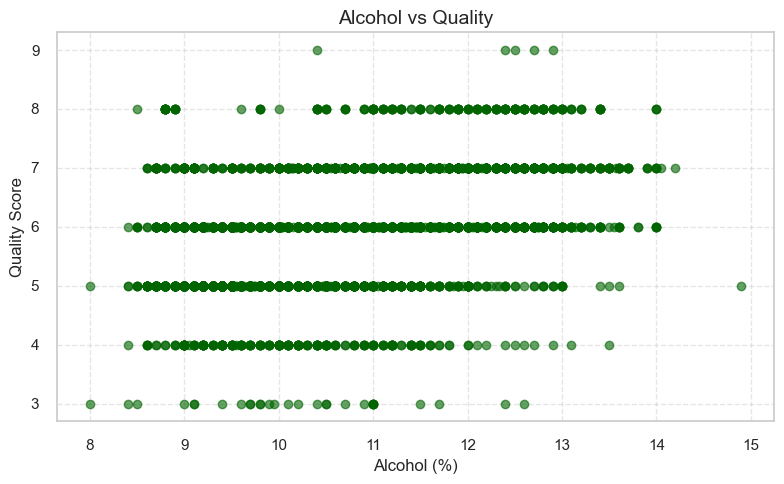

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    wine_df['alcohol'], 
    wine_df['quality'],
    color='darkgreen',
    alpha=0.6
)

plt.xlabel("Alcohol (%)", fontsize=12)
plt.ylabel("Quality Score", fontsize=12)
plt.title("Alcohol vs Quality", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The scatter plot shows a **positive relationship between alcohol content and wine quality**.  
Although the relationship is not perfectly linear, wines with higher alcohol levels tend to receive higher quality scores.

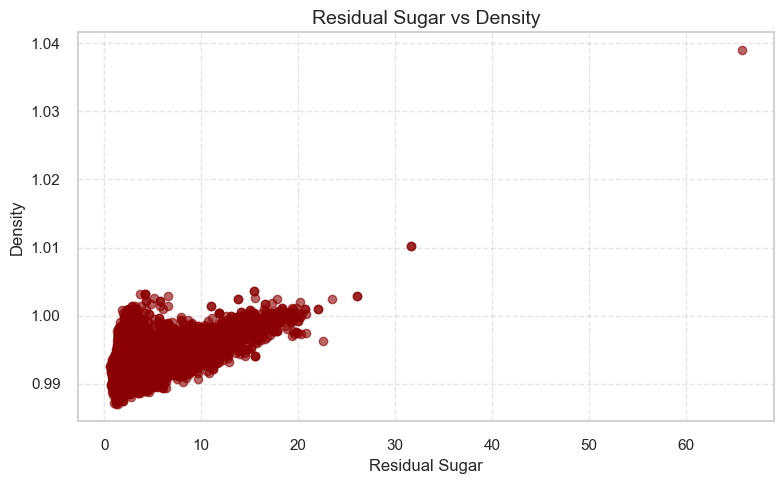

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    wine_df['residual sugar'], 
    wine_df['density'],
    color='darkred',
    alpha=0.6
)

plt.title("Residual Sugar vs Density", fontsize=14)
plt.xlabel("Residual Sugar", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Residual sugar shows a **positive relationship with wine density**, which is expected since dissolved sugars increase liquid density.  
However, the relationship contains some variability due to the influence of other chemical components.

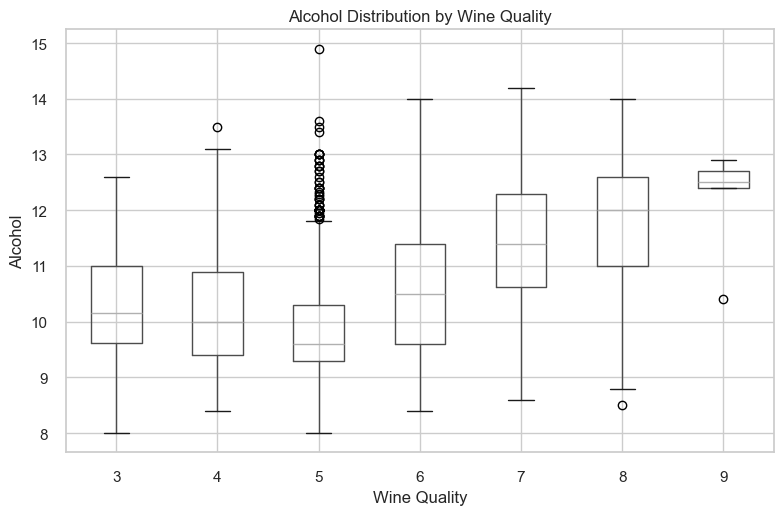

In [23]:
wine_df.boxplot(column='alcohol', by='quality')

plt.title("Alcohol Distribution by Wine Quality")
plt.suptitle("")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()

The boxplot shows that alcohol levels generally increase as wine quality increases.

Higher quality wines tend to have higher median alcohol content.

This suggests a positive relationship between alcohol content and wine quality.

However, some overlap exists between quality levels, indicating that alcohol alone does not fully determine wine quality.

---

## EDA Summary



From the exploratory data analysis, several key insights can be observed:

• The dataset contains **1,599 wine samples with no missing values**, making it suitable for modeling without heavy data cleaning.

• Wine quality scores range from **3 to 8**, with most samples concentrated around **5 and 6**, indicating a moderate class imbalance.

• **Alcohol content shows the strongest positive correlation with wine quality**, suggesting it may be one of the most important predictive features.

• **Volatile acidity tends to negatively correlate with wine quality**, indicating that higher acidity may reduce perceived wine quality.

• Several features contain **outliers**, particularly residual sugar and chlorides, but these may represent valid extreme wine compositions rather than errors.

• Relationships between some variables (such as **residual sugar and density**) reflect expected chemical behavior in wine composition.

Overall, the dataset shows meaningful relationships between physicochemical properties and wine quality, making it suitable for **machine learning models to predict wine quality based on chemical measurements.**

---

# Preprocessing

## TRAIN-TEST SPLIT

Model learns a mapping from X to y

In [27]:
X = wine_df.drop("quality", axis=1)
y = wine_df["quality"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Feature Engineering: Creating New Features from Wine Dataset

In [29]:
wine_df["total_acidity"] = wine_df["fixed acidity"] + wine_df["volatile acidity"]
wine_df["sugar_alcohol_ratio"] = wine_df["residual sugar"] / wine_df["alcohol"]
wine_df["density_alcohol_interaction"] = wine_df["density"] * wine_df["alcohol"]

total_acidity
This feature is the sum of fixed acidity and volatile acidity, representing the overall acidity of the wine.
It provides a more comprehensive measure of sourness, which is an important factor affecting wine quality.

sugar_alcohol_ratio
This feature is the ratio between residual sugar and alcohol, capturing the balance between sweetness and alcohol content.
This balance plays a key role in determining the taste and quality of wine.

density_alcohol_interaction
This feature is created by multiplying density and alcohol, representing the interaction between these two variables.

---


## Encoding

In [30]:
wine_df["type"] = wine_df["type"].map({"red": 0, "white": 1})
print(wine_df.dtypes)

fixed acidity                  float64
volatile acidity               float64
citric acid                    float64
residual sugar                 float64
chlorides                      float64
free sulfur dioxide            float64
total sulfur dioxide           float64
density                        float64
pH                             float64
sulphates                      float64
alcohol                        float64
quality                          int64
type                           float64
total_acidity                  float64
sugar_alcohol_ratio            float64
density_alcohol_interaction    float64
dtype: object
